In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
from langchain_groq import ChatGroq
# model=ChatGroq(model="qwen/qwen3.6-27b")
model=ChatGroq(model="openai/gpt-oss-120b")
print(model)
# print("hello world")

metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}} profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True} client=<groq.resources.chat.completions.Completions object at 0x000002065A194590> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002065A1952B0> model_name='openai/gpt-oss-120b' model_kwargs={} groq_api_key=SecretStr('**********')


In [2]:
from pydantic import BaseModel, Field
# node to fetch latest trending vide from the youtube using API.
class ReferenceVideo(BaseModel):
    title:str=Field(description="contains title of the video")
    description:str=Field(description="contains the description of the videos")
    channelTitle:str=Field(description="It is the title of youtube channel")
    tags:list[str]|str|None=Field(description="It contains the list of tags related to video")
import requests
def fetch_trending_video(state):
    video_id=state["video_id"]
    print("fetch trending video node called")
    # res= requests.get("https://abcd.com/")
    # data=res.json()
    # This is the data of that trending video
    data={
        "title":"US Iran War: ईरान पर अमेरिका की ताबड़तोड़ कार्रवाई! ट्रंप बोले- रडार और नौसैनिक ढांचा तबाह | AajTak",
        "channelTitle":"Aajtak",
        "tags":["usiranwar" ,"usattack ","trump ","atwebvideos ","aajtak  ","aajtakdigital" ,"tvchunks"],
        "description":"""ईरान और अमेरिका के बीच तनाव लगातार बढ़ता जा रहा है। अमेरिकी राष्ट्रपति डोनाल्ड ट्रंप ने दावा किया है कि अमेरिकी सेना ने ईरान के रडार और नौसैनिक ढांचे पर बेहद भारी हमले किए हैं। वहीं ईरान की ओर से अमेरिकी हमलों में एक शादी समारोह को निशाना बनाए जाने और बड़ी संख्या में लोगों के हताहत होने का दावा किया गया है।

इस बीच ईरान ने अमेरिकी MQ-9 रीपर ड्रोन को मार गिराने का दावा किया है। आर्थिक मोर्चे पर भी दबाव बढ़ रहा है, जबकि SCO सम्मेलन के दौरान पीएम मोदी और ईरानी राष्ट्रपति मसूद पेज़ेश्कियान की मुलाकात के बाद अमेरिका की ओर से ईरान की आर्थिक मदद या प्रतिबंधों को दरकिनार करने वाले देशों को चेतावनी दी गई है। आखिर ईरान-अमेरिका की इस जंग का अगला मोड़ क्या होगा? 
"""
        

    }
    required_data={}
    required_data["title"]=data["title"]
    required_data["description"]=data["description"]
    required_data["channelTitle"]=data["channelTitle"]
    required_data["tags"]=data["tags"]
    print("result of fetch trending vide node:",required_data)
    return {"refrence_video":required_data}
                


In [3]:
# from langchain_tavily import TavilySearch
# from langchain_core.tools import tool

# @tool
# def tavily_search_tool(query:str):
#     """This tool is for the websearch. It provides the latest possible data present on internet based on query asked. So queyr is passed to the tool and tool returns the data after performing websearch on the user query."""
#     print("here isthe tool called=>")
#     search_tool=TavilySearch(
#         max_results=2,
#         topic="news"
#     )
#     res=search_tool.invoke(query)
#     print("here is tool result==>",res)
#     return res


In [4]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from graph.prompts import RESEARCH_AGENT_SYSTEM_MESSAGE, RESEARCH_AGENT_SYSTEM_MESSAGE_TO_STRUCTURE
from datetime import datetime
from graph.tools import tavily_search_tool
class ReleventVideo(BaseModel):
    """Structure of an individual relevant video idea."""

    title: str = Field(
        description="Engaging, clickable, and search-optimized title."
    )
    summary: str = Field(
        description="2-3 sentence overview of the core concept and content flow."
    )
    viewer_hook: str = Field(
        description="Why the reference video viewer would click this."
    )
    relevancy_score: float = Field(
        description="Relevancy score compared to the reference video from 0.0 to 1.0."
    )


class ReleventVideos(BaseModel):
    """Container for the list of generated video ideas."""

    videos: list[ReleventVideo] = Field(
        description="List containing exactly 1 relevant video ideas.",
        min_length=1,
        max_length=1,
    )


def research_agent(state):
    """Researches trending updates and returns 1 validated, structured video concepts."""
    refrence_video = state["refrence_video"]
    current_date=datetime.now()

    # 1. Agent System Prompt: Guides web search & analysis
    agent_system_message = RESEARCH_AGENT_SYSTEM_MESSAGE.format(
        current_date=current_date,
        refrence_video_title=refrence_video.get("title", ""),
        refrence_video_channel_title=refrence_video.get("channelTitle", ""),
        refrence_video_description=refrence_video.get("description", ""),
        refrence_video_tags=refrence_video.get("tags", "")
        )
    agent = create_agent(
        model=model,
        tools=[tavily_search_tool],
        system_prompt=agent_system_message,
    )
    print("here agent decleration ended and agent invocation happen")
    agent_res = agent.invoke({
        "messages": [{
            "role": "user", 
            "content": "Research the latest facts and real-time updates for this video topic. Formulate 1 distinct video angles.",
            
        }]
    })
    print("here agent invocation has ended")
    agent_message = agent_res["messages"][-1].content

    # 2. Structured Output Prompt: Injects the agent's verified research

    structured_output_prompt = ChatPromptTemplate.from_messages([
        ("system", RESEARCH_AGENT_SYSTEM_MESSAGE_TO_STRUCTURE),
        (
            "human",
            """Below is the verified research report on this topic:

---
{research_data}
---

Generate the 1 structured video concept based on this verified research."""
        ),
    ])

    model_with_structured_output = model.with_structured_output(ReleventVideos)
    chain = structured_output_prompt | model_with_structured_output

    # 3. Invoke chain with reference metadata and research data
    result = chain.invoke({
        "ref_title": refrence_video.get("title", ""),
        "ref_channel": refrence_video.get("channelTitle", ""),
        "ref_desc": refrence_video.get("description", ""),
        "research_data": agent_message,
    })
    return {"relevent_videos":result.videos}

In [5]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from graph.prompts import FINAL_YOUTUBE_CONTENT_SYSTEM_PROMPT, FINAL_YOUTUBE_CONTENT_HUMAN_PROMPT

class RawVideoInput(BaseModel):
    title: str
    summary: str
    viewer_hook: str


class GeneratedVideoData(BaseModel):
    title: str = Field(
        description="High-CTR, curiosity-driven YouTube title under 65 characters without clickbait violation."
    )
    description: str = Field(
        description="SEO-optimized description containing an engaging 2-3-sentence hook, video summary, structured timestamps/key takeaways, and relevant hashtags."
    )
    tags: list[str] = Field(
        description="10 to 15 targeted keywords combining broad reach, niche tags, and long-tail search queries."
    )



def finalize_youtube_content(state):
    relevent_videos=state["relevent_videos"]
    inputs=[{"title":video.title if hasattr(video,"title") else video["title"],
             "summary":video.summary if hasattr(video,"summary") else video["summary"],
             "viewer_hook":video.viewer_hook if hasattr(video,"viewer_hook") else video["viewer_hook"]
             } for video in relevent_videos]

    prompt = ChatPromptTemplate.from_messages([
        ("system", FINAL_YOUTUBE_CONTENT_SYSTEM_PROMPT),
        ("human", FINAL_YOUTUBE_CONTENT_HUMAN_PROMPT),
    ])
    structured_model = model.with_structured_output(GeneratedVideoData)
    chain = prompt | structured_model
    final_video_data=chain.batch(inputs)
    print("here is the final_video data:",final_video_data)
    # return final_video_data
    return {"final_video_data":final_video_data}

In [6]:
from graph.tools import generate_thumb_image

class CombineVideoData(GeneratedVideoData):
    thumb_image:str=Field(description="It contains the thumb url of the video")

def generate_thumbnail(state):
    final_video_data=state["final_video_data"]
    inputs=[{"title":video.title,"description":video.description} for video in final_video_data]
    thumbnails=generate_thumb_image.batch(inputs)
    print("here are all the thumbnails==>",thumbnails)
    combined_videos = [
        {
            **video.model_dump(),     # Unpacks title, description, tags, etc.
            "thumb_image": thumb      # Adds the thumbnail result
        }
        for video, thumb in zip(final_video_data, thumbnails)
    ]
    
    print("Combined video package:", combined_videos)
    return {"final_video_package": combined_videos}

In [7]:
from typing_extensions import TypedDict
class State(TypedDict):
    video_id:str
    refrence_video:ReferenceVideo
    relevent_videos:ReleventVideos
    final_video_data:GeneratedVideoData
    final_video_package:CombineVideoData

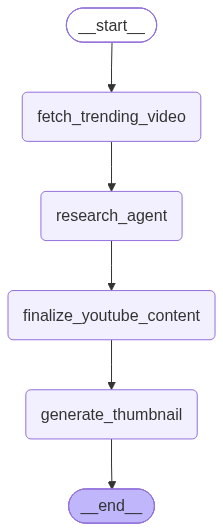

In [8]:
from langgraph.graph import StateGraph, START,END
from IPython.display import display, Image
builder=StateGraph(State)

builder.add_node("fetch_trending_video",fetch_trending_video)
builder.add_node("research_agent",research_agent)
builder.add_node("finalize_youtube_content",finalize_youtube_content)
builder.add_node("generate_thumbnail",generate_thumbnail)

builder.add_edge(START, "fetch_trending_video")
builder.add_edge("fetch_trending_video","research_agent")
builder.add_edge("research_agent","finalize_youtube_content")
builder.add_edge("finalize_youtube_content","generate_thumbnail")
builder.add_edge("generate_thumbnail",END)
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
res = graph.invoke(
    {"video_id": "abcd"},
    {"recursion_limit": 10}
)

fetch trending video node called
result of fetch trending vide node: {'title': 'US Iran War: ईरान पर अमेरिका की ताबड़तोड़ कार्रवाई! ट्रंप बोले- रडार और नौसैनिक ढांचा तबाह | AajTak', 'description': 'ईरान और अमेरिका के बीच तनाव लगातार बढ़ता जा रहा है। अमेरिकी राष्ट्रपति डोनाल्ड ट्रंप ने दावा किया है कि अमेरिकी सेना ने ईरान के रडार और नौसैनिक ढांचे पर बेहद भारी हमले किए हैं। वहीं ईरान की ओर से अमेरिकी हमलों में एक शादी समारोह को निशाना बनाए जाने और बड़ी संख्या में लोगों के हताहत होने का दावा किया गया है।\n\nइस बीच ईरान ने अमेरिकी MQ-9 रीपर ड्रोन को मार गिराने का दावा किया है। आर्थिक मोर्चे पर भी दबाव बढ़ रहा है, जबकि SCO सम्मेलन के दौरान पीएम मोदी और ईरानी राष्ट्रपति मसूद पेज़ेश्कियान की मुलाकात के बाद अमेरिका की ओर से ईरान की आर्थिक मदद या प्रतिबंधों को दरकिनार करने वाले देशों को चेतावनी दी गई है। आखिर ईरान-अमेरिका की इस जंग का अगला मोड़ क्या होगा? \n', 'channelTitle': 'Aajtak', 'tags': ['usiranwar', 'usattack ', 'trump ', 'atwebvideos ', 'aajtak  ', 'aajtakdigital', 'tvchunks']}
here ag

In [ ]:
res["final_video_package"]

[{'title': 'US‑Iran 2026 Clash: Radar Strike, Wedding Tragedy & Oil Route Crisis Explained',
  'description': 'If you saw the wedding‑hall bombing headlines, this video reveals the full story – the military tactics, the human cost, and why the world’s oil routes and super‑power alliances are on the line.\n\nDive into the September\u202f2026 US‑Iran flash‑point: from Trump’s massive radar‑and‑naval strike to Iran’s claim of downing a US MQ‑9 Reaper and the tragic wedding hall attack. Learn how drones, Strait‑of‑Hormuz logistics, and a new SCO‑driven sanctions‑evasion network are reshaping regional security and U.S. politics.\n\nTimestamps:\n0:00 – Intro & Hook\n1:45 – Radar & Naval Strike Overview\n4:20 – MQ‑9 Reaper Downed? Evidence & Claims\n7:05 – Wedding Hall Attack: Human Impact\n10:30 – Drone Warfare 101 (Beginner Friendly)\n13:15 – Strait of Hormuz Logistics & Oil Flow\n16:40 – Macro Analysis: Regional Power Shift\n20:05 – U.S. Domestic Political Fallout\n23:30 – Emerging SCO San